# 당뇨병 특성(BMI) 추출 및 데이터 분할 모델 훈련

- 사이킷런 내장 당뇨병 데이터셋(load_diabetes)에서 환자의 체질량지수(BMI) 수치를 독립 변수로 삼아 당뇨 수치 진행 상태를 예측하는 선형 회귀 모델을 만들어봅니다.

- 조건
  - TODO: Mission 1
    - load_diabetes 데이터셋을 로드하고, 특성 데이터의 2번째 컬럼(인덱스 2: bmi) 값만 추출하여 X_bmi 변수에 대입하세요.
      (2차원 데이터 구조를 유지하도록 X_df[:, [2]] 또는 데이터프레임으로 변환하여 열 선택)
    - train_test_split을 활용해 훈련데이터셋을 데이터의 80:20 비율로 분할하세요. (random_state=42 설정 필수)
    - Scikit-learn의 LinearRegression 모델을 정의하고 훈련 데이터로 학습시키세요.

  - TODO: Mission 2
    - Mission 1에서 훈련시킨 mission_model을 사용하여 테스트 데이터(X_test_b)에 대한 예측값 y_pred_b를 구하세요.
    - 실제값 y_test_b와 예측값 y_pred_b를 비교하여 MAE, MSE, RMSE, R2 Score를 각각 계산한 후 해당 변수에 대입하세요.

  - TODO: Mission 3
    - 테스트 세트 실제 데이터(X_test_b, y_test_b)의 산점도를 검은색(black) 점으로 그리세요.
    - 테스트 세트 예측값 회귀선(X_test_b, y_pred_b)을 붉은색(red) 실선으로 겹쳐 그리는 Matplotlib 차트를 구현해 보세요.

In [35]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import set_config
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

set_config(display="text") 

In [36]:
diabetes = load_diabetes()
X_raw = diabetes.data
y_raw = diabetes.target

In [37]:
# TODO: Mission 1 코드를작성하세요.
X_bmi = X_raw[:, [2]]

# 데이터 분할
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bmi,
    y_raw,
    test_size=0.2,
    random_state=42
)

# 모델 훈련
mission_model = LinearRegression()
mission_model.fit(X_train_b, y_train_b)

LinearRegression()

In [38]:
# TODO: Mission 2 코드를작성하세요.
y_pred_b = mission_model.predict(X_test_b)

mae_b = mean_squared_error(y_test_b, y_pred_b)
mse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
rmse_b = mean_absolute_error(y_test_b, y_pred_b)
r2_b = r2_score(y_test_b, y_pred_b)

print(f"당뇨병 BMI 선형회귀 평가결과:")
print(f"MAE: {mae_b}")
print(f"MSE: {mse_b}")
print(f"RMSE: {rmse_b}")
print(f"R2 Score: {r2_b}")

당뇨병 BMI 선형회귀 평가결과:
MAE: 4061.8259284949268
MSE: 63.73245584860925
RMSE: 52.25997644534553
R2 Score: 0.23335039815872138


In [39]:
# TODO: Mission 3 코드를작성하세요

import matplotlib.pyplot as plt

In [42]:
# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")

# -(음수 부호) 깨짐 방지
plt.rc("axes", unicode_minus=False)

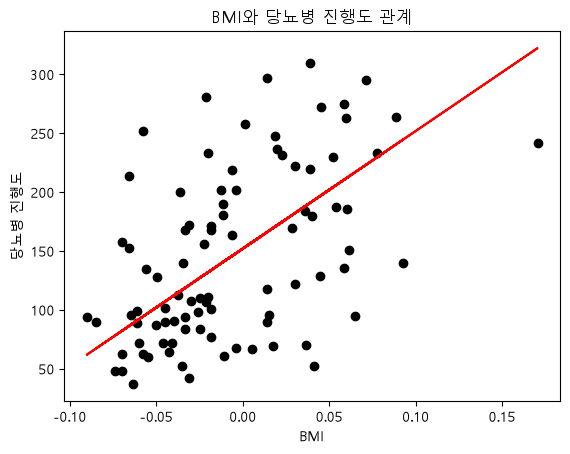

In [43]:
plt.scatter(X_test_b, y_test_b, color="black")
plt.plot(X_test_b, y_pred_b, color="red")

plt.title("BMI와 당뇨병 진행도 관계")
plt.xlabel("BMI")
plt.ylabel("당뇨병 진행도")

plt.show()

In [44]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

In [45]:
# 랜덤 포레스트 모델 생성
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [46]:
# 모델 학습
rf_model.fit(X_train_b, y_train_b)

RandomForestRegressor(random_state=42)

In [47]:
# 예측
y_pred_rf = rf_model.predict(X_test_b)

In [48]:
# 평가
mae_rf = mean_absolute_error(y_test_b, y_pred_rf)
mse_rf = mean_squared_error(y_test_b, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test_b, y_pred_rf)

In [50]:
print("당뇨병 BMI Random Forest 평가결과:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

당뇨병 BMI Random Forest 평가결과:
MAE: 50.759719353056425
MSE: 4293.168013439725
RMSE: 65.52227112547095
R2: 0.18968572113062931


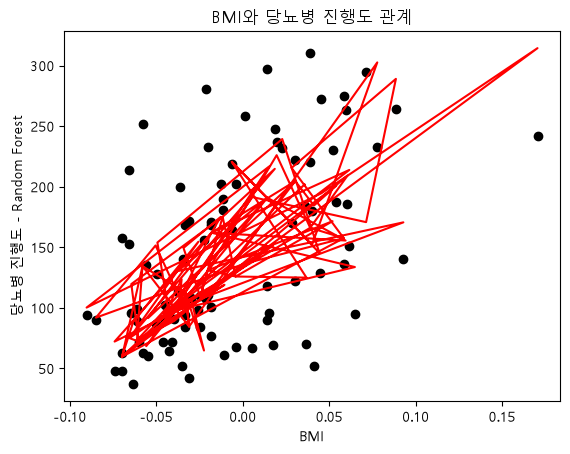

In [52]:
plt.scatter(X_test_b, y_test_b, color="black")
plt.plot(X_test_b, y_pred_rf, color="red")

plt.title("BMI와 당뇨병 진행도 관계")
plt.xlabel("BMI")
plt.ylabel("당뇨병 진행도 - Random Forest")

plt.show()